In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import Dash, html, dash_table, dcc
from dash.dependencies import Input, Output
import dash_bootstrap_components as dbc

In [2]:
students = pd.read_csv("./student-por.csv")
students

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [3]:
fig = px.scatter(
    students, x='absences', y='G3', color='sex', color_discrete_map={
        'F': 'hotpink',
        'M': 'dodgerblue'})
fig

In [4]:
# students.drop(columns=students.loc[-1:-4]).columns
grade_cols = students.columns[-3:]
#grade_cols = students.iloc[:, -3:].columns
grade_cols #For grade dropdown!

Index(['G1', 'G2', 'G3'], dtype='object')

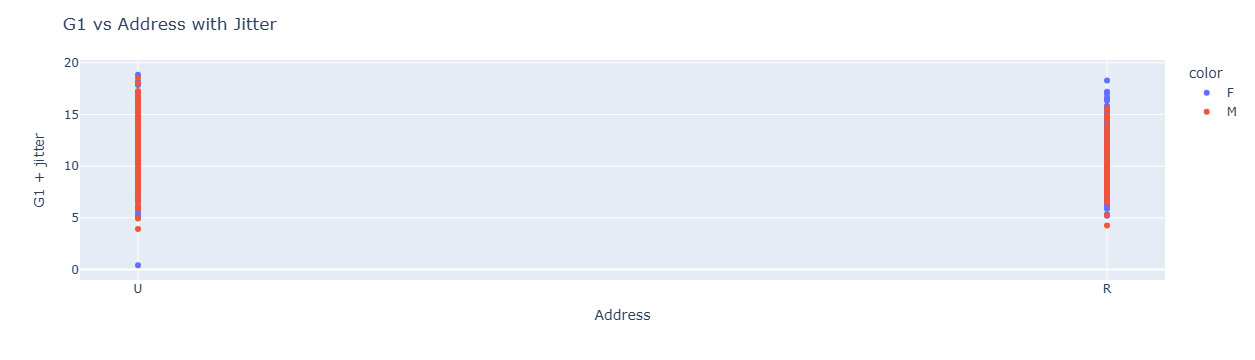

In [5]:
# x_noise = np.random.normal(0,0.5,len(students))
# fig2 = px.scatter(x = students['address'], y = students['G1'] + x_noise, color = students['sex'])
# fig2
y_noise = np.random.normal(0, 0.3, len(students))  # smaller spread than before
y_vals = students['G1'] + y_noise

fig2 = px.scatter(
    x=students['address'],
    y=y_vals,
    color=students['sex'],
    labels={"x":"Address", "y":"G1 + jitter"},
)

fig2.update_layout(
    title="G1 vs Address with Jitter",
    xaxis=dict(type='category')
)

fig2.show()

#Do a dropdown menu to choose different grades for this

In [6]:
#grouped_grades = students.groupby('')

In [7]:
# fig3 = px.line(students, x = '')

In [8]:
#fig4 = px.imshow()
fig4 = px.density_heatmap(students, x = 'Mjob', y = 'health') #Need to show average of health, not count
fig4 # And then a dropdown to change between different parents' jobs (like mother vs father)

In [9]:
students

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [10]:
grouped_absences = students.groupby(['Mjob', 'Fjob'], as_index=False)[['G1', 'G2', 'G3']].mean()
grouped_absences #Would like to make a graph for this with two dropdowns (one for each parent's job)

,Mjob,Fjob,G1,G2,G3
0,at_home,at_home,11.388889,11.388889,11.833333
1,at_home,health,10.000000,11.000000,11.000000
2,at_home,other,10.454545,10.766234,11.090909
3,at_home,services,10.250000,10.222222,10.555556
4,at_home,teacher,6.000000,11.000000,11.000000
5,health,at_home,8.000000,10.000000,9.000000
6,health,health,13.222222,13.333333,13.777778
7,health,other,12.285714,12.619048,13.047619
8,health,services,11.933333,12.000000,12.533333
9,health,teacher,15.500000,16.000000,16.000000


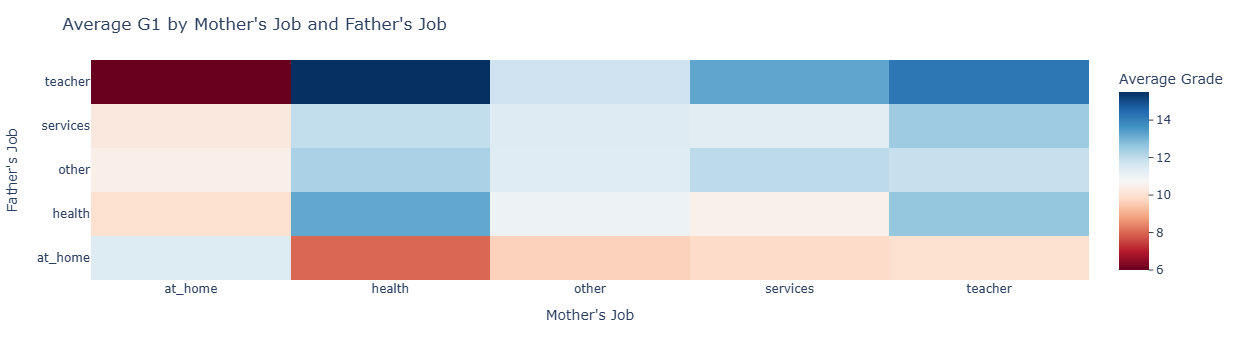

In [11]:
new_heatmap = px.density_heatmap(
    grouped_absences,
    x='Mjob',
    y='Fjob',
    z='G1',
    histfunc='avg',
    color_continuous_scale='RdBu'
)

new_heatmap.update_layout(
    title="Average G1 by Mother's Job and Father's Job",
    xaxis_title="Mother's Job",
    yaxis_title="Father's Job",
    coloraxis_colorbar=dict(
        title="Average Grade",
        ticks="outside"
    )
)

new_heatmap

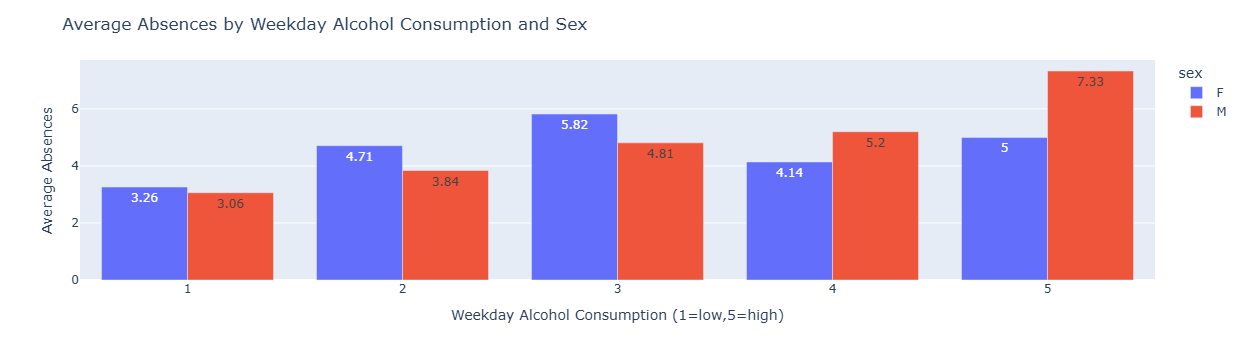

In [30]:
# Third Figure:

# students['absences_scaled'] = students['absences'] / students['absences'].max() * 50  # max size 50
# students['freetime_scaled'] = students['freetime'] / students['freetime'].max() * 50
# students['failures_scaled'] = students['failures'] / students['failures'].max() * 50

# fig3 = px.scatter(
#     students,
#     x='traveltime',
#     y='studytime',
#     size='absences_scaled',    # Bubble size
# color='internet',          # Toggle-able later
#     hover_data=['age','sex','famsize','absences','studytime'],
#     labels={
#         'traveltime': 'Travel Time to School',
#         'studytime': 'Weekly Study Time',
#         'internet': 'Internet Access',
#         'size': 'Absences (scaled)'
#     },
#     title="Travel Time vs Study Time Bubble Chart"
# )

# fig3.update_layout(
#     xaxis=dict(tickmode='linear', tick0=1, dtick=1),
#     yaxis=dict(tickmode='linear', tick0=1, dtick=1)
# )

# fig3.show()

# absences_by_travel = students.groupby('traveltime', as_index=False)['absences'].mean()

# fig4 = px.bar(
#     absences_by_travel,
#     x='traveltime',
#     y='absences',
#     labels={
#         'traveltime': 'Travel Time (1=<15min, 2=15-30min, 3=30-60min, 4=>1hr)',
#         'absences': 'Average Absences'
#     },
#     title="Average Absences by Travel Time"
# )

# fig4.show()

grouped = students.groupby(['Dalc', 'Walc', 'sex'], as_index=False)['absences'].mean()

# # grouped['Dalc'] = grouped['Dalc'].astype(str)

# fig_bars = px.bar(grouped, x='Dalc', y='absences', color='sex', barmode='group',   # side-by-side bars
#     labels={'Dalc': 'Weekday Alcohol Consumption (1=low, 5=high)',
#             'absences': 'Average Absences',
#             'sex': 'Sex'}
# )

# fig_bars.update_layout(
#     title="Average Absences by Alcohol Consumption and Sex",
#     xaxis_title="Weekday Alcohol Consumption",
#     yaxis_title="Average Number of Absences"
# )

# fig_bars.show()


agg = students.groupby(['Dalc','sex'], as_index=False)['absences'].mean()
agg['absences'] = agg['absences'].round(2)

fig4 = px.bar(
    agg,
    x='Dalc',         # weekday alcohol level
    y='absences',     # average absences
    color='sex',      # split by sex
    barmode='group',  # side-by-side bars (paired)
    labels={'Dalc':'Weekday Alcohol Consumption (1=low,5=high)',
            'absences':'Average Absences'},
    text='absences'   # optional: show numbers on bars
)

fig4.update_layout(
    title="Average Absences by Weekday Alcohol Consumption and Sex",
    xaxis=dict(type='category')  # ensure Dalc treated as categorical
)

fig4.show()


In [74]:
# absences_by_travel

In [3]:
# Do an opacity slider

# PUT FINISHED APP IN PYTHON FILE!!! WITH assets folder with styles.css

In [36]:
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
     dbc.Row([html.H1("Student Information Dashboard"),
         dbc.Col([
             dcc.Graph(id='scatterplot')
         ], width = 9),

         dbc.Col([
             dcc.Dropdown(
                 id ='Grade Period Select', 
                 options=grade_cols,
                 value = 'G1',
                 clearable =False
             )
         ], width = 3)
     ], align='center'),

    dbc.Row([
         dbc.Col([
             dcc.Graph(id='heatmap')
         ], width = 9),

         dbc.Col([
             dcc.Dropdown(
                 id ='Grade Heatmap Select', 
                 options=grade_cols,
                 value = 'G1',
                 clearable = False
             ),
             dbc.Switch(
                id='heatmap_color_flip',
                label='Invert Colors',
                value=False,
                className='mt-2'
            )
             
         ], width = 3)
     ], align='center'),

    dbc.Row([
         dbc.Col([
             dcc.Graph(id='barplot')
         ], width = 9),

         dbc.Col([
             dbc.Switch(
                 id ='Bar Mode', 
                 label = 'Grouped or Stacked',
                 value = True,
                 className ='mt-2'
             )
         ], width = 3)
     ], align='center')

    
])



@app.callback(
    [Output('scatterplot', 'figure'), 
    Output('heatmap', 'figure'),
    Output('barplot', 'figure')],
    Input('Grade Period Select', 'value'),
    Input('Grade Heatmap Select', 'value'),
    Input('Bar Mode', 'value'),
    Input('heatmap_color_flip', 'value')
)

                           
def update_plot(grade, grade_avg_for_heatmap, bar_mode, flip_colors):
    
    fig = px.scatter(students, x='absences', y=grade, color='sex', color_discrete_map={
        'F': 'hotpink',
        'M': 'dodgerblue'})

    colorscale = 'RdBu_r' if flip_colors else 'RdBu'

    new_heatmap = px.density_heatmap(grouped_absences, x='Mjob', y='Fjob', z=grade_avg_for_heatmap, histfunc='avg', color_continuous_scale=colorscale)
    
    new_heatmap.update_layout(
        title="Average G1 by Mother's Job and Father's Job",
        xaxis_title="Mother's Job",
        yaxis_title="Father's Job",
        coloraxis_colorbar=dict(
            title="Average Grade",
            ticks="outside"
        )
    )
    
    barmode_value = 'group' if bar_mode else 'stack'

    fig4 = px.bar(
        agg, x='Dalc', y='absences', color='sex', color_discrete_map={
        'F': 'hotpink',
        'M': 'dodgerblue'}, barmode=barmode_value, labels={'Dalc':'Weekday Alcohol Consumption (1=low,5=high)', 'absences':'Average Absences'}, text='absences'   # optional: show numbers on bars
    )

    fig4.update_layout(
        title="Average Absences by Weekday Alcohol Consumption and Sex",
        xaxis=dict(type='category')  # ensure Dalc treated as categorical
    )

    
    
    return fig, new_heatmap, fig4

# Run the app
if __name__ == '__main__':
    app.run(debug=True)